In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1764849593.320542 4178029 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [7]:
print(gender_predictions)

[[4.1919878e-01]
 [4.9501192e-04]
 [1.5451779e-03]
 [1.5846473e-03]
 [3.9950735e-04]
 [3.1694566e-04]
 [1.9896902e-04]
 [1.7797938e-03]
 [1.7445516e-02]
 [1.0459913e-02]
 [1.7264670e-03]
 [7.1863190e-04]
 [9.8821602e-04]
 [2.5647996e-02]
 [1.1942686e-02]
 [1.7815025e-03]
 [6.4600195e-04]
 [3.6175677e-04]
 [7.8359974e-04]
 [1.1308039e-02]
 [7.4028515e-04]
 [1.3104879e-03]
 [1.3737665e-03]
 [1.4505963e-04]
 [4.3727228e-04]
 [2.3561675e-04]
 [1.1312034e-03]
 [8.3089998e-04]
 [6.5032486e-04]
 [8.7468093e-04]
 [8.6570048e-04]
 [1.9024480e-03]
 [1.2987360e-03]
 [7.0281816e-04]
 [1.3981789e-03]
 [6.9755927e-04]
 [1.1929373e-03]
 [5.1642460e-04]
 [2.8660235e-03]
 [1.3483443e-03]
 [5.3430488e-04]
 [2.1478827e-03]
 [2.9651914e-04]
 [1.4282330e-02]
 [4.5739273e-03]
 [1.4123720e-03]
 [2.6296489e-03]
 [5.8135862e-04]
 [5.0366315e-04]
 [9.9883896e-01]
 [9.9994862e-01]
 [9.9769890e-01]
 [9.9017072e-01]
 [9.9815196e-01]
 [9.9781358e-01]
 [9.9978679e-01]
 [9.9639881e-01]
 [9.9749607e-01]
 [9.9693990e-0

In [8]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 299 female samples.


In [9]:
df.shape

(299, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297,1,5,8
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250,1,6,8
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741,1,2,8
52,-317.351776,121.372276,-17.553547,53.506031,-19.536947,32.461872,-7.048652,2.529278,-0.955572,-5.793414,...,55.835431,-0.042968,-0.024235,-0.001901,-0.071230,0.004682,0.009318,1,3,8
53,-316.035004,78.327827,-75.185143,44.491062,-43.997913,21.882950,-25.612417,-10.069695,-2.338615,-14.442650,...,55.231352,0.002748,-0.002888,-0.029788,0.001539,-0.000088,-0.006368,1,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [11]:
data.iloc[:,-3] == 0 #male

0       True
1       True
2       True
3       True
4       True
       ...  
530    False
531    False
532    False
533    False
534    False
Name: gender, Length: 535, dtype: bool

In [12]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,15.609642,18.692301,17.012600,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,14.983087,16.689537,17.606614,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,16.867387,18.443066,17.613748,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741
52,-317.351776,121.372276,-17.553547,53.506031,-19.536947,32.461872,-7.048652,2.529278,-0.955572,-5.793414,...,14.594819,17.331695,16.874626,55.835431,-0.042968,-0.024235,-0.001901,-0.071230,0.004682,0.009318
53,-316.035004,78.327827,-75.185143,44.491062,-43.997913,21.882950,-25.612417,-10.069695,-2.338615,-14.442650,...,18.035402,17.966467,17.961476,55.231352,0.002748,-0.002888,-0.029788,0.001539,-0.000088,-0.006368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [14]:
y

49     5
50     6
51     2
52     3
53     1
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 299, dtype: int64

In [15]:
X_speaker

49      8
50      8
51      8
52      8
53      8
       ..
530    16
531    16
532    16
533    16
534    16
Name: speaker, Length: 299, dtype: int64

In [16]:
X.shape, y.shape

((299, 193), (299,))

In [17]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [18]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [19]:
y1

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(299, 7))

In [20]:
X.shape, y1.shape

((299, 193), (299, 7))

In [21]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [22]:
X2.shape, X2_speaker.shape, y2.shape

((299, 193), (299,), (299,))

In [23]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [24]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [25]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-279.096466,70.186913,-75.673683,31.503792,-37.293854,4.894505,-14.134119,-13.924743,-12.761198,-16.300407,...,18.815330,17.717460,20.117418,56.320224,0.000491,0.016024,-0.045316,-0.062933,-0.008509,0.002165
1,-196.153351,61.573624,-66.337166,71.401947,-39.169395,13.426764,-31.778332,-10.184829,-7.434160,-23.351307,...,17.292589,17.867397,18.674767,56.258996,-0.036457,0.000975,0.094340,0.042450,-0.012736,-0.011981
2,-267.695984,130.485062,-18.768496,44.961082,-30.714767,32.502247,-8.279457,-5.297762,-7.307362,-8.644254,...,13.907923,17.084653,16.409386,54.703477,0.001098,-0.041694,-0.063638,0.043800,0.033014,-0.026210
3,-240.040649,127.937119,-17.678284,45.866421,-12.429788,16.101721,-14.934668,-0.078793,-10.138142,-18.306551,...,16.721176,18.797012,17.793838,55.433317,-0.061430,0.043839,0.200741,-0.131093,-0.018425,0.050532
4,-188.980957,116.812424,-29.256758,56.455708,-7.854492,31.449286,-1.978740,-2.460175,0.108518,2.265104,...,14.825879,17.581420,18.566779,56.420162,-0.036612,-0.067457,-0.100588,-0.124180,-0.002348,0.028633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,-290.403992,114.075981,-10.132744,60.238880,-11.949096,28.772326,-1.801645,3.048955,-2.876461,-6.929398,...,13.455511,15.972513,17.199427,57.094609,-0.009759,0.020566,0.026268,0.009828,0.006808,0.005352
295,-264.294495,131.931122,-24.973824,68.815804,-16.511599,16.421537,1.076068,-7.368456,-1.254634,-4.601353,...,15.229591,17.344541,19.992863,54.660835,-0.041079,-0.067554,-0.151698,-0.031234,0.034187,-0.030993
296,-267.656097,79.630531,-55.695938,27.406511,-29.934868,10.334890,-17.297575,0.268291,-16.292261,-17.258669,...,16.307983,17.474602,16.618136,58.454917,0.021202,0.008438,-0.006530,-0.060584,0.019180,-0.012449
297,-278.924500,74.042053,-13.847912,56.202126,3.001628,22.006252,2.346364,-4.327850,2.359917,1.087441,...,14.729751,16.002207,17.479628,59.377124,0.023007,0.001055,0.134485,-0.069501,0.025289,0.003226


In [26]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,16
1,16
2,14
3,8
4,9
...,...
294,14
295,9
296,13
297,16


In [27]:
speakers = X_speaker.unique()
speakers

array([16, 14,  8,  9, 13])

In [28]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,16
1,16
2,14
3,8
4,9
...,...
294,14
295,9
296,13
297,16


In [29]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-279.096466,70.186913,-75.673683,31.503792,-37.293854,4.894505,-14.134119,-13.924743,-12.761198,-16.300407,...,17.717460,20.117418,56.320224,0.000491,0.016024,-0.045316,-0.062933,-0.008509,0.002165,16
1,-196.153351,61.573624,-66.337166,71.401947,-39.169395,13.426764,-31.778332,-10.184829,-7.434160,-23.351307,...,17.867397,18.674767,56.258996,-0.036457,0.000975,0.094340,0.042450,-0.012736,-0.011981,16
2,-267.695984,130.485062,-18.768496,44.961082,-30.714767,32.502247,-8.279457,-5.297762,-7.307362,-8.644254,...,17.084653,16.409386,54.703477,0.001098,-0.041694,-0.063638,0.043800,0.033014,-0.026210,14
3,-240.040649,127.937119,-17.678284,45.866421,-12.429788,16.101721,-14.934668,-0.078793,-10.138142,-18.306551,...,18.797012,17.793838,55.433317,-0.061430,0.043839,0.200741,-0.131093,-0.018425,0.050532,8
4,-188.980957,116.812424,-29.256758,56.455708,-7.854492,31.449286,-1.978740,-2.460175,0.108518,2.265104,...,17.581420,18.566779,56.420162,-0.036612,-0.067457,-0.100588,-0.124180,-0.002348,0.028633,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,-290.403992,114.075981,-10.132744,60.238880,-11.949096,28.772326,-1.801645,3.048955,-2.876461,-6.929398,...,15.972513,17.199427,57.094609,-0.009759,0.020566,0.026268,0.009828,0.006808,0.005352,14
295,-264.294495,131.931122,-24.973824,68.815804,-16.511599,16.421537,1.076068,-7.368456,-1.254634,-4.601353,...,17.344541,19.992863,54.660835,-0.041079,-0.067554,-0.151698,-0.031234,0.034187,-0.030993,9
296,-267.656097,79.630531,-55.695938,27.406511,-29.934868,10.334890,-17.297575,0.268291,-16.292261,-17.258669,...,17.474602,16.618136,58.454917,0.021202,0.008438,-0.006530,-0.060584,0.019180,-0.012449,13
297,-278.924500,74.042053,-13.847912,56.202126,3.001628,22.006252,2.346364,-4.327850,2.359917,1.087441,...,16.002207,17.479628,59.377124,0.023007,0.001055,0.134485,-0.069501,0.025289,0.003226,16


In [30]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(5).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [16 14 13  8  9]


In [31]:
def fisher_score_manual(X, y):
    n_samples, n_features = X.shape
    classes = np.unique(y)
    score = np.zeros(n_features)
    for i in range(n_features):
        numerator = 0
        denominator = 0
        overall_mean = np.mean(X[:, i])
        for c in classes:
            Xc = X[y==c, i]
            nc = len(Xc)
            mean_c = np.mean(Xc)
            var_c = np.var(Xc)
            numerator += nc * (mean_c - overall_mean)**2
            denominator += nc * var_c
        score[i] = numerator / denominator if denominator != 0 else 0
    return score

In [33]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=295
num_fea=125
a=create_index(kfold,totalsize)
top_features_per_fold = []
importance_per_fold = []

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emodb_speaker_female'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score_manual(X_train_scaled, y_train_fs)

    # Sort features by score (high → low)
    sorted_indices = np.argsort(score)[::-1]

    # Select top features
    fs_indices = sorted_indices[:num_fea]

    # Get scores of selected features
    selected_scores = score[fs_indices]

    # Compute relative importance (percentage)
    relative_importance = selected_scores / selected_scores.sum() * 100

    top_features_per_fold.append(fs_indices)
    importance_per_fold.append(relative_importance)



===== Fold 0 =====
Test speaker: 16
Train speakers: [ 8  9 13 14]
No overlap in fold 0.

===== Fold 1 =====
Test speaker: 14
Train speakers: [ 8  9 13 16]
No overlap in fold 1.

===== Fold 2 =====
Test speaker: 13
Train speakers: [ 8  9 14 16]
No overlap in fold 2.

===== Fold 3 =====
Test speaker: 8
Train speakers: [ 9 13 14 16]
No overlap in fold 3.

===== Fold 4 =====
Test speaker: 9
Train speakers: [ 8 13 14 16]
No overlap in fold 4.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

num_folds = 5

# Collect all unique features
all_features = sorted(set(np.concatenate(top_features_per_fold)))

df = pd.DataFrame(0.0, index=all_features, columns=range(kfold), dtype=float)

for fold_idx in range(kfold):
    indices = top_features_per_fold[fold_idx]
    importance = importance_per_fold[fold_idx]
    df.loc[indices, fold_idx] = importance

# Average importance across folds
df['avg_importance'] = df.mean(axis=1)

# Sort by average importance
df_sorted = df['avg_importance'].sort_values(ascending=True)


In [35]:
df_sorted.values[-10:]

array([1.74299743, 1.75704186, 1.77012676, 2.21281105, 2.27024051,
       2.39570585, 2.67232955, 2.97393722, 3.16015056, 3.65845735])

In [36]:
df_sorted.index[-10:].astype(str)

Index(['182', '184', '58', '181', '183', '5', '6', '180', '4', '2'], dtype='object')

In [31]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=300
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emodb_speaker_female'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 14
Train speakers: [ 3  8  9 10 13 15 16]
No overlap in fold 0.
Top 125 features: [65 16  0 32  2  4  3 50 13 18] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.1617 - loss: 2.2486 - val_accuracy: 0.1739 - val_loss: 1.9344
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3702 - loss: 1.6950 - val_accuracy: 0.1449 - val_loss: 1.9398
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4426 - loss: 1.5088 - val_accuracy: 0.1159 - val_loss: 1.9491
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5574 - loss: 1.3437 - val_accuracy: 0.1159 - val_loss: 1.9589
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5660 - loss: 1.2458 - val_accuracy: 0.1739 - val_loss: 1.9688
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6851 - loss: 1.1331 - val_accuracy: 0.1449 - val_loss: 1.9774
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6723 - loss: 1.1261 - val_accuracy: 0.1449 - val_loss: 1.9845
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7191 - loss: 1.0261 - val_accuracy: 0.1159 - val_loss: 1.9888
Epoc

Fold 0 Test Accuracy: 0.7536

===== Fold 1 =====
Test speaker: 16
Train speakers: [ 3  8  9 10 13 14 15]
No overlap in fold 1.
Top 125 features: [105   8   0  42   4   6   5  39  21  26] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.1877 - loss: 2.1555 - val_accuracy: 0.1395 - val_loss: 1.9489
Epoch 2/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4100 - loss: 1.5913 - val_accuracy: 0.0930 - val_loss: 1.9529
Epoch 3/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4789 - loss: 1.4957 - val_accuracy: 0.1163 - val_loss: 1.9558
Epoch 4/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5556 - loss: 1.3006 - val_accuracy: 0.0930 - val_loss: 1.9574
Epoch 5/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6207 - loss: 1.2382 - val_accuracy: 0.1395 - val_loss: 1.9492
Epoch 6/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6858 - loss: 1.1225 - val_accuracy: 0.2558 - val_loss: 1.9442
Epoch 7/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7663 - loss: 1.0338 - val_accuracy: 0.2558 - val_loss: 1.9365
Epoch 8/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7701 - loss: 0.9577 - val_accuracy: 0.2326 - val_loss: 1.9257
Epo

Fold 4 Test Accuracy: 0.5349

===== Cross-validation results =====
Fold 0: Loss=1.3065, Accuracy=0.7536
Fold 1: Loss=1.4231, Accuracy=0.5362
Fold 2: Loss=1.2520, Accuracy=0.7049
Fold 3: Loss=1.2330, Accuracy=0.7414
Fold 4: Loss=1.4844, Accuracy=0.5349

Average accuracy: 0.6542


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'emodb_speaker_female'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-02 12:30:26.690162: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 12:30:26.690383: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:30:26.718904: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:30:27.367515: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 75.36%
              precision    recall  f1-score   support

       angry     0.7500    0.7500    0.7500        16
       bored     0.7143    0.6250    0.6667         8
     neutral     0.7143    0.7143    0.7143         7
     disgust     0.6667    1.0000    0.8000         8
        fear     0.8750    0.5833    0.7000        12
       happy     0.6250    0.6250    0.6250         8
         sad     0.9091    1.0000    0.9524        10

    accuracy                         0.7536        69
   macro avg     0.7506    0.7568    0.7440        69
weighted avg     0.7629    0.7536    0.7487        69


Fold 1: Accuracy = 53.62%
              precision    recall  f1-score   support

       angry     0.4242    1.0000    0.5957        14
       bored     0.7143    0.7143    0.7143        14
     neutral     0.3333    0.2500    0.2857         4
     disgust     0.5000    0.5000    0.5000        10
        fear     1.0000    0.1429    0.2500         7
       happy     0.6000 

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi


Fold 3: Accuracy = 74.14%
              precision    recall  f1-score   support

       angry     1.0000    1.0000    1.0000        12
       bored     0.8333    1.0000    0.9091        10
     neutral     1.0000    0.5000    0.6667        10
     disgust     0.0000    0.0000    0.0000         0
        fear     0.3750    0.5000    0.4286         6
       happy     0.6667    0.3636    0.4706        11
         sad     0.9000    1.0000    0.9474         9

    accuracy                         0.7414        58
   macro avg     0.6821    0.6234    0.6318        58
weighted avg     0.8279    0.7414    0.7592        58


Fold 4: Accuracy = 53.49%
              precision    recall  f1-score   support

       angry     0.7500    0.6923    0.7200        13
       bored     0.3077    1.0000    0.4706         4
     neutral     0.7500    0.3333    0.4615         9
     disgust     1.0000    0.2500    0.4000         8
        fear     0.3333    1.0000    0.5000         1
       happy     0.2857 

/tmp/ipykernel_218925/733101130.py:7: RuntimeWarning: invalid value encountered in divide
  conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100


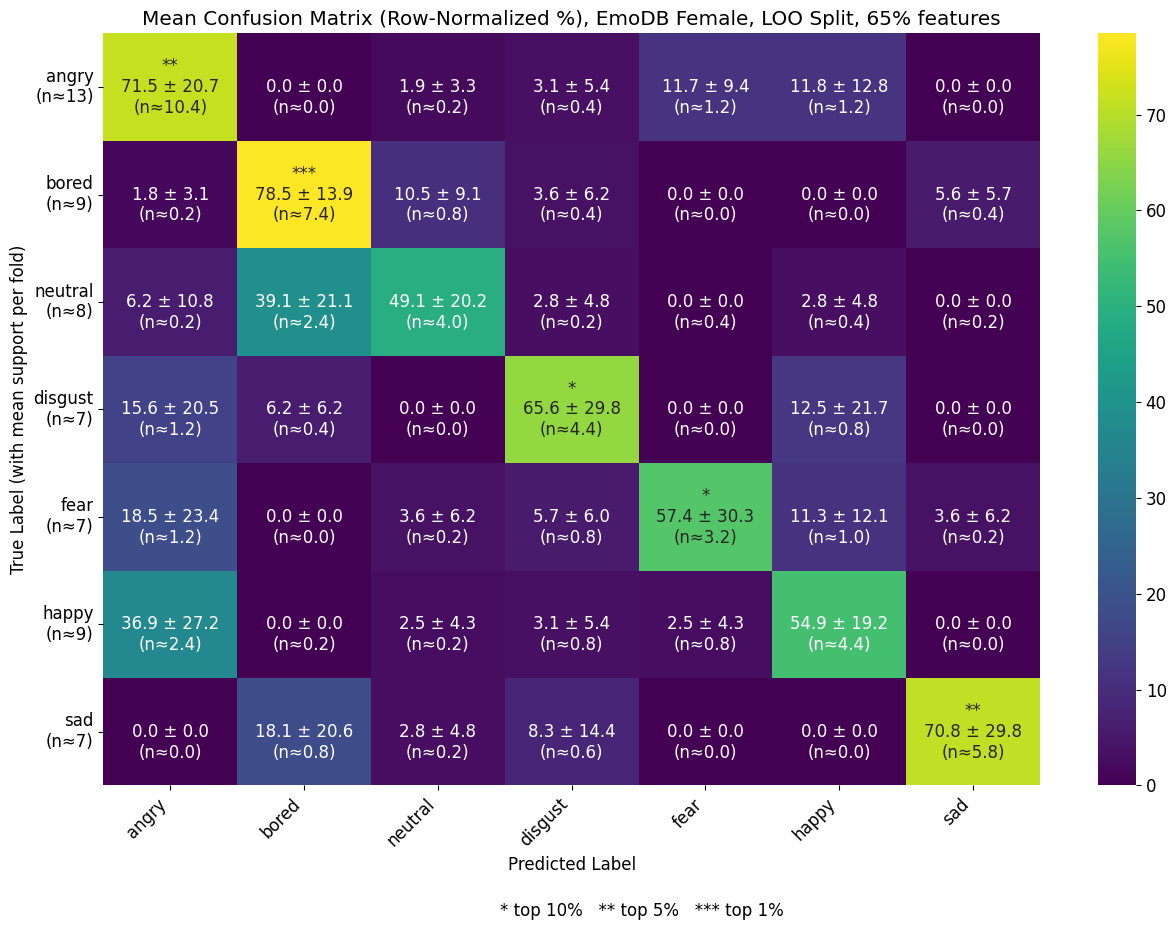

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

valid_folds = conf_matrices.sum(axis=2)[:, 3] > 0  # index 3 = disgust
conf_matrices_percent = conf_matrices_percent[valid_folds]

np.save('cm_emodb_speaker_female.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), EmoDB Female, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.savefig("cm_emodb_speaker_female.eps", bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'emodb_speaker_male'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices_male = []

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices_male.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices_male = np.array(conf_matrices_male)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(



Fold 0: Accuracy = 67.27%
              precision    recall  f1-score   support

       angry     0.7647    1.0000    0.8667        13
       bored     0.5000    0.3333    0.4000         9
     neutral     1.0000    0.7273    0.8421        11
     disgust     1.0000    0.2500    0.4000         4
        fear     0.6250    0.6250    0.6250         8
       happy     0.7500    0.5000    0.6000         6
         sad     0.3636    1.0000    0.5333         4

    accuracy                         0.6727        55
   macro avg     0.7148    0.6337    0.6096        55
weighted avg     0.7345    0.6727    0.6630        55


Fold 1: Accuracy = 74.55%
              precision    recall  f1-score   support

       angry     0.9000    0.8182    0.8571        11
       bored     1.0000    0.5000    0.6667         8
     neutral     0.7273    0.8889    0.8000         9
     disgust     0.2500    0.5000    0.3333         2
        fear     1.0000    0.7000    0.8235        10
       happy     0.7143 

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent_male = conf_matrices_male / conf_matrices_male.sum(axis=2, keepdims=True) * 100

valid_folds = conf_matrices_male.sum(axis=2)[:, 3] > 0  # index 3 = disgust
conf_matrices_percent_male = conf_matrices_percent_male[valid_folds]

mean_cm_2 = np.mean(conf_matrices_percent_male, axis=0)
std_cm_2 = np.std(conf_matrices_percent_male, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm_2.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels_2 = np.empty(mean_cm_2.shape, dtype=object)
for i in range(mean_cm_2.shape[0]):
    for j in range(mean_cm_2.shape[1]):
        val = mean_cm_2[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels_2[i, j] = f"{symbol}\n{val:.1f} ± {std_cm_2[i, j]:.1f}"


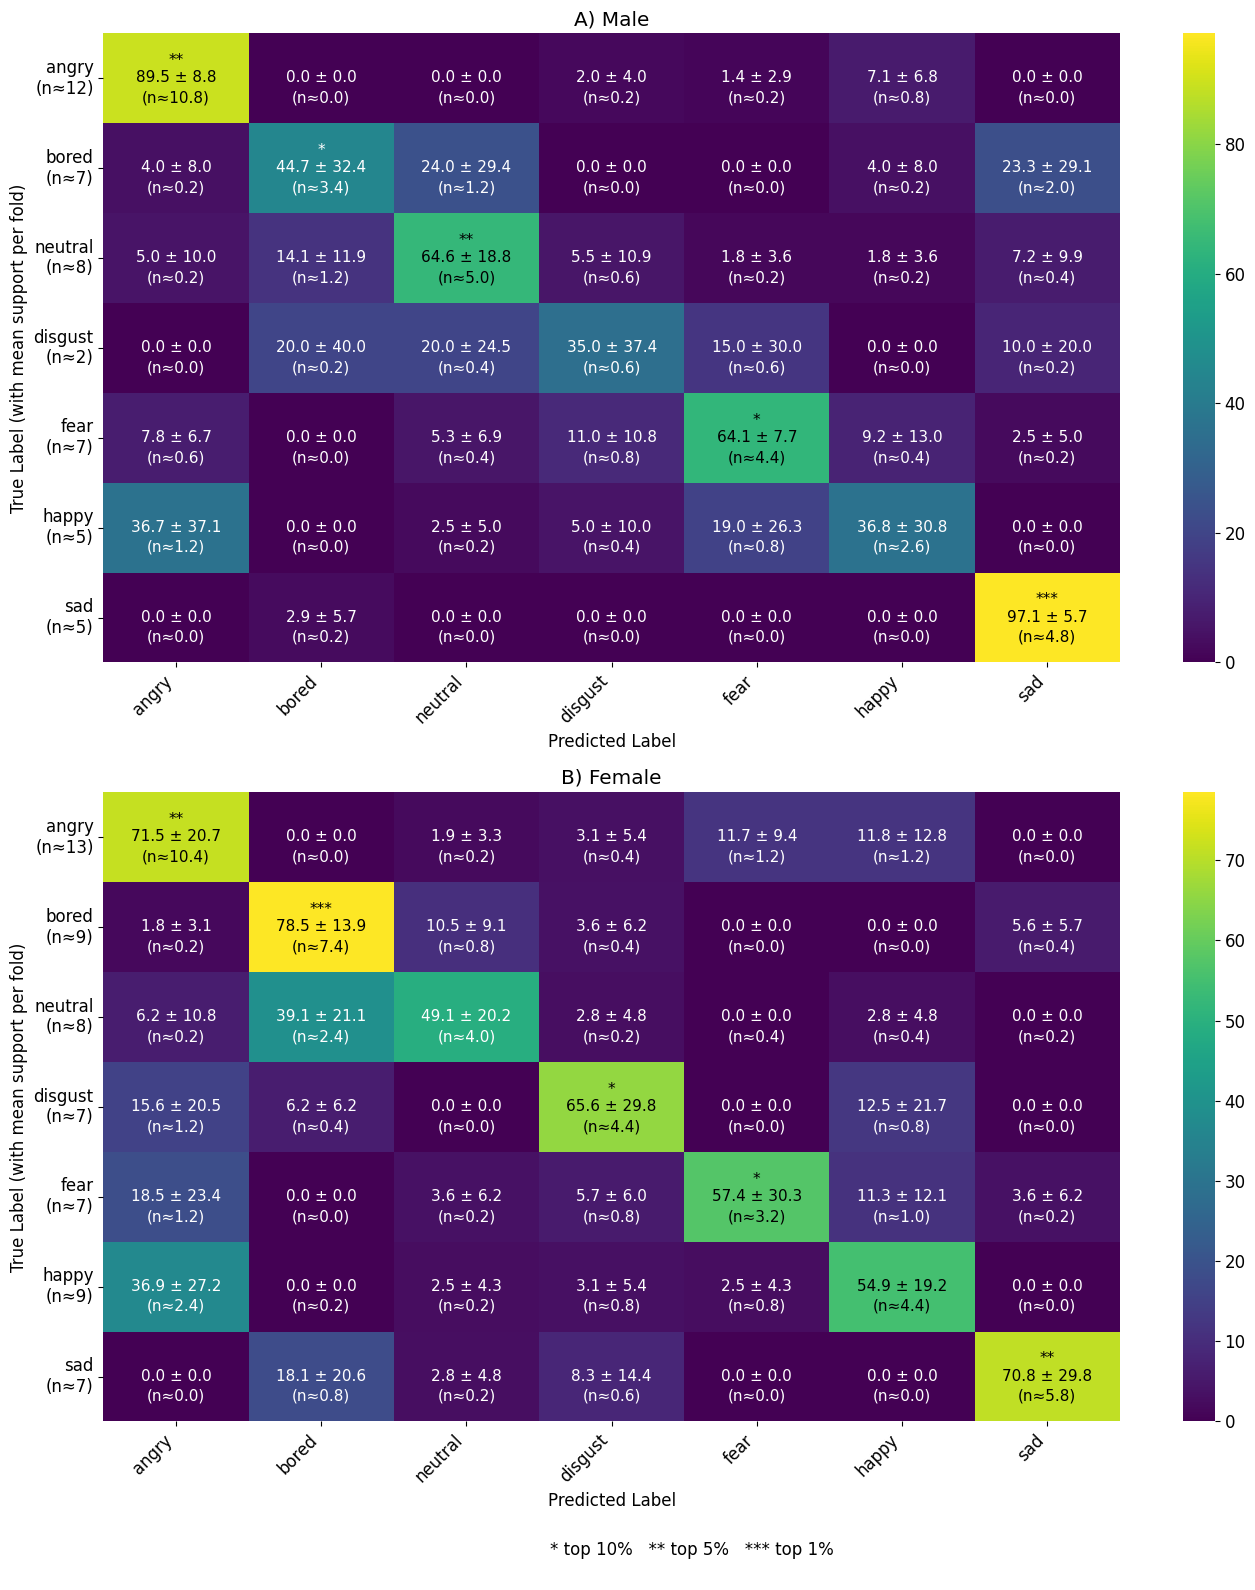

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})
listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Helper function for manual two-size annotations
def annotate_heatmap(ax, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99):
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            val = mean_cm[i, j]
            symbol = ""
            if val >= thr_99:
                symbol = "***"
            elif val >= thr_95:
                symbol = "**"
            elif val >= thr_90:
                symbol = "*"

            text_color = "white" if val < 50 else "black"

            main_text = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"
            ax.text(j + 0.5, i + 0.4, main_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)

            count_text = f"(n≈{mean_counts[i, j]:.1f})"
            ax.text(j + 0.5, i + 0.72, count_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)
            

# For female (conf_matrices is the raw count matrices)
mean_counts = np.mean(conf_matrices, axis=0)

# For male (conf_matrices_2 is the raw count matrices)
mean_counts_2 = np.mean(conf_matrices_male, axis=0)

# ---------------------------------------
# A) Male heatmap (TOP)
# ---------------------------------------
ax1 = axes[0]

flat_vals_2 = mean_cm_2.flatten()
thr_90_2 = np.percentile(flat_vals_2, 90)
thr_95_2 = np.percentile(flat_vals_2, 95)
thr_99_2 = np.percentile(flat_vals_2, 99)

mean_support_2 = np.mean(conf_matrices_male.sum(axis=2), axis=0)
row_labels_2 = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support_2)]

sns.heatmap(mean_cm_2, annot=False, cmap="viridis", cbar=True, ax=ax1)
annotate_heatmap(ax1, mean_cm_2, std_cm_2, mean_counts_2, thr_90_2, thr_95_2, thr_99_2)

ax1.set_xticks(np.arange(len(listik)) + 0.5)
ax1.set_yticks(np.arange(len(listik)) + 0.5)
ax1.set_xticklabels(listik, rotation=45, ha="right")
ax1.set_yticklabels(row_labels_2, rotation=0)
ax1.set_title("A) Male")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label (with mean support per fold)")

# ---------------------------------------
# B) Female heatmap (BOTTOM)
# ---------------------------------------
ax2 = axes[1]

flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

sns.heatmap(mean_cm, annot=False, cmap="viridis", cbar=True, ax=ax2)
annotate_heatmap(ax2, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99)

ax2.set_xticks(np.arange(len(listik)) + 0.5)
ax2.set_yticks(np.arange(len(listik)) + 0.5)
ax2.set_xticklabels(listik, rotation=45, ha="right")
ax2.set_yticklabels(row_labels, rotation=0)
ax2.set_title("B) Female")
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label (with mean support per fold)")

# Shared caption
fig.text(0.5, 0.01,
         "* top 10%   ** top 5%   *** top 1%\n",
         ha="center", fontsize=12)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("cm_emodb_speaker_ab.eps", bbox_inches='tight')
plt.show()